# 01. Raw 데이터 품질 진단

## 분석 개요

- **목적**: `events`의 규모·기간·결측, 일별 수집 추이, 가격·반복 이벤트·세션 품질을 확인해 02 분석 테이블 생성 규칙을 확정한다.
- **분석 단위**: 품질 항목에 따라 이벤트, 일자×이벤트 유형, 세션을 구분한다. 각 표와 차트에 분모를 명시한다.
- **관측 기간**: 데이터의 `MIN(event_time)`과 `MAX(event_time)`으로 확인한다.
- **캐시 기준**: 공통 `QueryCache`가 named SQL, SQL 파일 hash, dataset version, DB source, 결과 행 수·내용 hash·생성 시각을 함께 검증한다. 출처 정보가 없는 기존 flat cache는 사용하지 않는다.
- **제한**: 원본 이벤트 로그를 수정하지 않으며 관찰 결과를 수집 원인이나 사용자 행동의 원인으로 단정하지 않는다.

In [1]:
import json
import os
import sys
from pathlib import Path
from urllib.parse import quote_plus

import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from IPython.display import display
from dotenv import load_dotenv
from sqlalchemy import create_engine

PROJECT_ROOT = next(
    (base for base in (Path.cwd(), *Path.cwd().parents)
     if (base / 'cache_context.json').is_file() and (base / 'sql').is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(f'프로젝트 루트를 찾을 수 없다 (cwd={Path.cwd()})')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

load_dotenv(PROJECT_ROOT / '.env')
engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{quote_plus(os.getenv('DB_PASSWORD'))}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}?charset=utf8mb4"
)
pio.renderers.default = 'plotly_mimetype'
COLORS = {
    'view': '#3B82F6', 'cart': '#F59E0B',
    'remove_from_cart': '#EF4444', 'purchase': '#10B981',
}

In [2]:
from query_cache import QueryCache, load_queries

SQL_FILE = PROJECT_ROOT / 'sql' / '01_raw_eda.sql'
Q = load_queries(SQL_FILE)
EXPECTED_QUERIES = [
    'base_scalars', 'distinct_users', 'distinct_sessions', 'daily_trend',
    'negative_price_detail', 'repeat_by_event', 'session_quality',
]
if list(Q) != EXPECTED_QUERIES:
    raise ValueError(f'named query 구성이 다르다: {list(Q)}')

QUERY_CACHE = QueryCache(
    engine=engine,
    sql_file=SQL_FILE,
    upstream_sql_files=(),
)

def run(name):
    return QUERY_CACHE.run(name)

REGRESSION_REFERENCE = {
    '전체 행 수': 20_692_840,
    '고유 사용자 수': 1_639_358,
    '고유 세션 수': 4_535_941,
    'category_code 결측': 20_339_246,
    'brand 결측': 8_757_117,
    'user_session 결측': 4_598,
    'category_id 결측': 0,
    'price 결측': 0,
    'price 음수': 131,
    'price 0원': 104_157,
    '반복 그룹 수': 1_045_761,
    '반복 초과 행 수': 1_109_099,
    '다중 user 세션 수': 272,
    '1일 초과 세션 수': 36_195,
}
regression_rows = []

def record_regression(metric, current):
    reference = REGRESSION_REFERENCE[metric]
    regression_rows.append({
        '지표': metric, '기존 저장값': reference,
        '현재 계산값': int(current), '일치': int(current) == reference,
    })

---
## 1. 데이터 규모·기간·결측

이벤트 전체를 분모로 규모·관측 기간·필수 컬럼 결측을 확인한다. 고유 사용자와 고유 세션은 각각 인덱스 선두 컬럼을 사용하도록 별도 쿼리로 계산한다.

In [3]:
base = run('base_scalars')
distinct_users = run('distinct_users')
distinct_sessions = run('distinct_sessions')
base_row = base.iloc[0]
total_rows = int(base_row['행수'])
user_n = int(distinct_users.iloc[0]['고유_사용자'])
session_n = int(distinct_sessions.iloc[0]['고유_세션'])

overview = pd.DataFrame([{
    '이벤트_행수': total_rows,
    '관측_시작': pd.Timestamp(base_row['시작']),
    '관측_종료': pd.Timestamp(base_row['종료']),
    '고유_사용자': user_n,
    '고유_세션': session_n,
}])
null_map = {
    'category_code': 'null_category_code', 'brand': 'null_brand',
    'user_session': 'null_user_session', 'category_id': 'null_category_id',
    'price': 'null_price',
}
null_profile = pd.DataFrame([
    {
        '컬럼': column,
        '결측수': int(base_row[source]),
        '결측률_pct': int(base_row[source]) / total_rows * 100,
    }
    for column, source in null_map.items()
])

record_regression('전체 행 수', total_rows)
record_regression('고유 사용자 수', user_n)
record_regression('고유 세션 수', session_n)
for metric, source in [
    ('category_code 결측', 'null_category_code'), ('brand 결측', 'null_brand'),
    ('user_session 결측', 'null_user_session'), ('category_id 결측', 'null_category_id'),
    ('price 결측', 'null_price'), ('price 음수', 'price_음수'), ('price 0원', 'price_0원'),
]:
    record_regression(metric, base_row[source])

display(overview)
null_profile.style.format({'결측수': '{:,.0f}', '결측률_pct': '{:.3f}%'})

[base_scalars] cache HIT 6d43091c3e2d · 1행
[distinct_users] cache HIT 2891d02b1215 · 1행
[distinct_sessions] cache HIT e7e32d4248b3 · 1행


,이벤트_행수,관측_시작,관측_종료,고유_사용자,고유_세션
0,20692840,2019-10-01,2020-02-29 23:59:59,1639358,4535941


,컬럼,결측수,결측률_pct
0,category_code,"20,339,246",98.291%
1,brand,"8,757,117",42.320%
2,user_session,"4,598",0.022%
3,category_id,0,0.000%
4,price,0,0.000%


---
## 2. 일별 수집 추이

일자×`event_type`의 이벤트 수를 확인한다. 수집 이상 판단에 사용되지 않았던 일별 고유 사용자 DISTINCT 집계는 제거했다. 날짜 또는 이벤트 유형이 통째로 비는지와 일별 건수 변동을 확인하되, 변동의 원인은 원본 이벤트 로그만으로 단정하지 않는다.

In [4]:
daily_trend = run('daily_trend')
daily_trend['event_date'] = pd.to_datetime(daily_trend['event_date'])
event_types = ['view', 'cart', 'remove_from_cart', 'purchase']
observed_days = daily_trend['event_date'].nunique()
calendar_days = (daily_trend['event_date'].max() - daily_trend['event_date'].min()).days + 1
daily_total = daily_trend.groupby('event_date', as_index=False)['event_count'].sum()
type_totals = (
    daily_trend.groupby('event_type', as_index=False)['event_count'].sum()
    .rename(columns={'event_count': '유형_전체_이벤트'})
)
collection_summary = pd.DataFrame([{
    '관측_일수': observed_days,
    '달력_일수': calendar_days,
    '누락_일수': calendar_days - observed_days,
    '일자×유형_행수': len(daily_trend),
    '완전한_일자×4유형': len(daily_trend) == observed_days * len(event_types),
    '일별_최소_이벤트': int(daily_total['event_count'].min()),
    '일별_최대_이벤트': int(daily_total['event_count'].max()),
}])
collection_summary

[daily_trend] cache HIT 720112d119df · 608행


,관측_일수,달력_일수,누락_일수,일자×유형_행수,완전한_일자×4유형,일별_최소_이벤트,일별_최대_이벤트
0,152,152,0,608,True,31096,270074


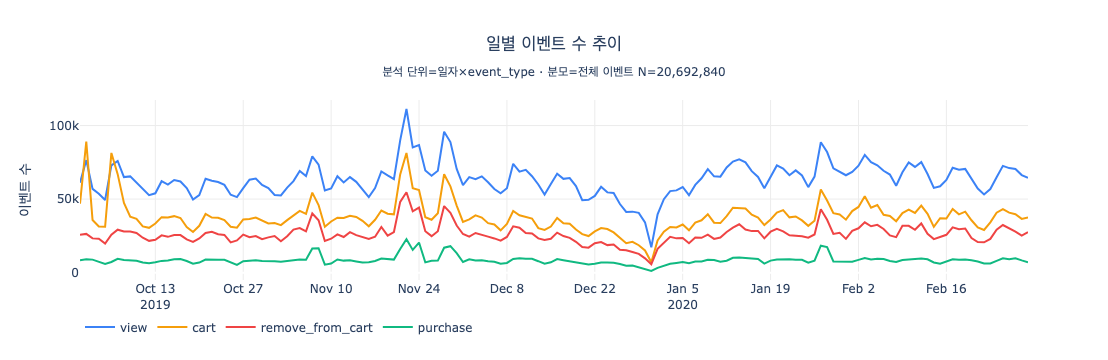

In [5]:
fig = go.Figure()
for event_type in event_types:
    subset = daily_trend[daily_trend['event_type'] == event_type]
    fig.add_trace(go.Scatter(
        x=subset['event_date'], y=subset['event_count'],
        mode='lines', name=event_type,
        line={'color': COLORS[event_type]},
    ))
fig.update_layout(
    title={
        'text': (
            f'일별 이벤트 수 추이<br><sub>분석 단위=일자×event_type · '
            f'분모=전체 이벤트 N={total_rows:,}</sub>'
        ),
        'x': 0.5, 'xanchor': 'center',
    },
    plot_bgcolor='white',
    xaxis={'gridcolor': '#ececec'},
    yaxis={'gridcolor': '#ececec', 'title': '이벤트 수'},
    legend={'orientation': 'h', 'y': -0.18},
)
fig.show()

> ### 일별 수집 추이 결론
>
> - 152개 달력 일자가 모두 관측됐고, 각 날짜에 네 이벤트 유형이 모두 존재해 날짜·유형 단위의 완전 누락은 확인되지 않았다.
> - 일별 전체 이벤트 수는 31,096-270,074건 범위다. 변동은 확인되지만 원본 이벤트 로그만으로 수집 환경이나 사용자 행동의 원인을 단정하지 않는다.

---
## 3. 가격 품질과 처리 방침

이벤트 전체를 분모로 가격 부호를 확인하고, 음수 가격은 상품·유형별 소량 상세를 조회한다. `price <= 0`의 월별 규모는 `daily_trend` 결과에서 파생한다.

In [6]:
negative_price_detail = run('negative_price_detail')
price_sign = pd.DataFrame([
    {'가격_구분': '음수', '이벤트수': int(base_row['price_음수'])},
    {'가격_구분': '0원', '이벤트수': int(base_row['price_0원'])},
    {'가격_구분': '양수', '이벤트수': int(base_row['price_정상'])},
])
price_sign['전체_대비_pct'] = price_sign['이벤트수'] / total_rows * 100
monthly_price = daily_trend.assign(월=daily_trend['event_date'].dt.strftime('%Y-%m'))
monthly_price = (
    monthly_price.groupby('월', as_index=False)
    .agg(가격_0이하=('zero_neg_count', 'sum'), 전체_이벤트=('event_count', 'sum'))
)
monthly_price['비율_pct'] = monthly_price['가격_0이하'] / monthly_price['전체_이벤트'] * 100

display(price_sign.style.format({'이벤트수': '{:,.0f}', '전체_대비_pct': '{:.3f}%'}))
display(monthly_price.style.format({'가격_0이하': '{:,.0f}', '전체_이벤트': '{:,.0f}', '비율_pct': '{:.3f}%'}))
negative_price_detail

[negative_price_detail] cache HIT f2a641f3ed61 · 9행


,가격_구분,이벤트수,전체_대비_pct
0,음수,131,0.001%
1,0원,"104,157",0.503%
2,양수,"20,588,552",99.496%


,월,가격_0이하,전체_이벤트,비율_pct
0,2019-10,"6,086","4,102,283",0.148%
1,2019-11,"11,642","4,635,837",0.251%
2,2019-12,"7,607","3,533,286",0.215%
3,2020-01,"7,662","4,264,752",0.180%
4,2020-02,"71,291","4,156,682",1.715%


,product_id,brand,price,event_type,건수,최초,최종
0,5670257,None,-15.87,purchase,39,2019-10-03 18:25:39,2020-02-25 14:07:40
1,5716857,None,-23.81,purchase,34,2019-10-01 19:10:56,2020-02-26 08:33:10
2,5716859,None,-47.62,purchase,30,2019-10-03 17:37:04,2020-02-29 11:41:09
3,5716855,None,-7.94,purchase,12,2019-10-02 08:30:03,2020-02-29 07:15:17
4,5716861,None,-79.37,purchase,11,2019-10-14 17:33:24,2020-02-11 12:38:33
5,5716857,None,-23.81,remove_from_cart,2,2020-02-29 17:10:44,2020-02-29 17:11:27
6,5716857,None,-23.81,view,1,2020-01-05 10:49:53,2020-01-05 10:49:53
7,5716859,None,-47.62,remove_from_cart,1,2020-01-13 11:26:36,2020-01-13 11:26:36
8,5716861,None,-79.37,view,1,2020-01-27 08:04:32,2020-01-27 08:04:32


> ### 가격 처리 결론
>
> - 음수 가격은 131건이다. 원본 이벤트 로그만으로 성격을 확정할 수 없으므로 02의 이벤트 카운트와 revenue에서 제외한다.
> - 0원은 104,157건이다. 행동 이벤트는 보존하되 금액 기여가 없으므로 이벤트 카운트에는 포함하고 revenue에서는 제외한다.
> - 따라서 02의 이벤트 집계 조건은 `price >= 0`, revenue 조건은 `event_type='purchase' AND price > 0`을 유지한다.

---
## 4. 반복 이벤트와 중복 처리 방침

동일 `user_session × event_time × product_id × event_type` 네 항목이 모두 같은 그룹과 대표 1행을 넘는 초과 행을 유형별로 확인한다. 이는 완전 동일 행 검사가 아니며, 자동 중복 제거 기준으로 사용하지 않는다.

In [7]:
repeat_by_event = run('repeat_by_event')
repeat_by_event['반복_포함_행수'] = (
    repeat_by_event['반복_그룹수'] + repeat_by_event['초과_행수']
)
repeat_by_event = repeat_by_event.merge(type_totals, on='event_type', how='left')
repeat_by_event['초과율_pct'] = (
    repeat_by_event['초과_행수'] / repeat_by_event['유형_전체_이벤트'] * 100
)
repeat_total = pd.DataFrame([{
    '반복_그룹수': int(repeat_by_event['반복_그룹수'].sum()),
    '반복_포함_행수': int(repeat_by_event['반복_포함_행수'].sum()),
    '초과_행수': int(repeat_by_event['초과_행수'].sum()),
}])
record_regression('반복 그룹 수', repeat_total.iloc[0]['반복_그룹수'])
record_regression('반복 초과 행 수', repeat_total.iloc[0]['초과_행수'])

display(repeat_total)
repeat_by_event.style.format({
    '반복_그룹수': '{:,.0f}', '초과_행수': '{:,.0f}',
    '반복_포함_행수': '{:,.0f}', '유형_전체_이벤트': '{:,.0f}',
    '초과율_pct': '{:.3f}%',
})

[repeat_by_event] cache HIT f78bc4ca9664 · 4행


,반복_그룹수,반복_포함_행수,초과_행수
0,1045761,2154860,1109099


,event_type,반복_그룹수,초과_행수,반복_포함_행수,유형_전체_이벤트,초과율_pct
0,remove_from_cart,"953,387","991,821","1,945,208","3,979,679",24.922%
1,cart,"90,502","115,342","205,844","5,768,333",2.000%
2,view,969,"1,031","2,000","9,657,821",0.011%
3,purchase,903,905,"1,808","1,287,007",0.070%


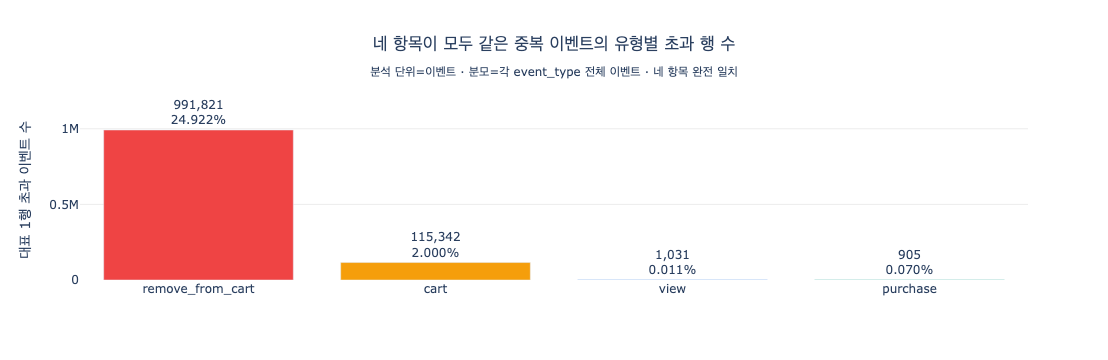

In [8]:
fig = go.Figure(go.Bar(
    x=repeat_by_event['event_type'],
    y=repeat_by_event['초과_행수'],
    marker_color=[COLORS[value] for value in repeat_by_event['event_type']],
    text=[
        f"{int(count):,}<br>{rate:.3f}%"
        for count, rate in zip(repeat_by_event['초과_행수'], repeat_by_event['초과율_pct'])
    ],
    textposition='outside',
    cliponaxis=False,
))
fig.update_layout(
    title={
        'text': (
            '네 항목이 모두 같은 중복 이벤트의 유형별 초과 행 수<br>'
            '<sub>분석 단위=이벤트 · 분모=각 event_type 전체 이벤트 · 네 항목 완전 일치</sub>'
        ),
        'x': 0.5, 'xanchor': 'center',
    },
    plot_bgcolor='white',
    yaxis={
        'gridcolor': '#ececec',
        'title': '대표 1행 초과 이벤트 수',
        # 막대 바깥 레이블 2줄이 잘리지 않도록 축 상단에 여유를 둔다.
        'range': [0, repeat_by_event['초과_행수'].max() * 1.20],
    },
    showlegend=False,
)
fig.show()

> ### 반복 이벤트 처리 결론
>
> - 네 항목 반복은 1,045,761개 그룹, 대표 1행을 넘는 초과분은 1,109,099행이다.
> - 초과분은 `remove_from_cart`에 집중되지만 네 항목 밖의 가격·원본 순번을 이용해 대표행을 정할 근거가 없다.
> - 반복 이벤트를 임의로 제거하지 않고 원본 횟수를 보존한다. 유형별 카운트를 해석할 때 반복 가능성을 함께 명시한다.

---
## 5. 세션 유효성

`user_session IS NOT NULL`인 세션을 한 번 집계해 세션당 고유 사용자 수와 시작-종료 지속시간을 동시에 확인한다. 분석 단위와 분모는 고유 `user_session`이다.

In [9]:
session_quality = run('session_quality')
session_row = session_quality.iloc[0]
session_quality_table = pd.DataFrame([
    {'항목': '02 유효 세션', '세션수': int(session_row['유효_세션수'])},
    {'항목': 'user_id 1개', '세션수': int(session_row['단일_user_세션수'])},
    {'항목': 'user_id 2개 이상', '세션수': int(session_row['다중_user_세션수'])},
    {'항목': '1시간 이하', '세션수': int(session_row['1시간_이하_세션수'])},
    {'항목': '1시간 초과·1일 이하', '세션수': int(session_row['1시간_초과_1일_이하_세션수'])},
    {'항목': '1일 초과', '세션수': int(session_row['1일_초과_세션수'])},
])
session_quality_table['고유_세션_대비_pct'] = session_quality_table['세션수'] / session_n * 100
record_regression('다중 user 세션 수', session_row['다중_user_세션수'])
record_regression('1일 초과 세션 수', session_row['1일_초과_세션수'])
session_quality_table.style.format({'세션수': '{:,.0f}', '고유_세션_대비_pct': '{:.3f}%'})

[session_quality] cache HIT 7bb902547f1b · 1행


,항목,세션수,고유_세션_대비_pct
0,02 유효 세션,"4,499,479",99.196%
1,user_id 1개,"4,535,669",99.994%
2,user_id 2개 이상,272,0.006%
3,1시간 이하,"4,361,378",96.152%
4,1시간 초과·1일 이하,"138,368",3.050%
5,1일 초과,"36,195",0.798%


> ### 세션 유효성 결론
>
> - `user_session` 결측 4,598행은 세션 경계를 식별할 수 없어 세션 분석 테이블에서 제외한다.
> - 한 세션에 여러 `user_id`가 연결된 272개 세션은 사용자 귀속이 모호해 제외한다.
> - 지속시간이 1일을 초과하는 36,195개 세션은 일반적인 세션 경계로 해석하기 어려워 제외한다.
> - 02 유효 행 조건은 `user_session IS NOT NULL`, 세션당 고유 `user_id = 1`, 세션 지속시간 `<= 1일`, 이벤트 카운트 `price >= 0`이다.

---
## 6. 확정 규칙과 02 인계

기존 저장 결과와 현재 계산 결과를 비교하고, 이번 SQL·dataset 출처 정보에 대응하는 7개 캐시의 무결성 메타데이터를 확인한다.

In [10]:
regression_check = pd.DataFrame(regression_rows)
cache_rows = []
for name in EXPECTED_QUERIES:
    fingerprint = QUERY_CACHE.fingerprint(name)
    metadata_path = (
        PROJECT_ROOT / 'cache' / SQL_FILE.stem / name / f'{fingerprint}.meta.json'
    )
    metadata = json.loads(metadata_path.read_text(encoding='utf-8'))
    cache_rows.append({
        'query': name,
        'fingerprint': fingerprint[:12],
        'SQL_file_hash': metadata['fingerprint_components']['sql_file_sha256'][:12],
        'dataset_version': metadata['fingerprint_components']['dataset_version'],
        '생성시각_UTC': metadata['created_at_utc'],
        '결과행수': metadata['row_count'],
        'content_hash': metadata['content_hash_sort_independent'][:12],
    })
# dataset_version은 7개 캐시가 동일해야 한다. 표에 반복하면 잘려서 확인이 불가능하므로
# 동일 여부를 검사한 뒤 표에서 빼고 한 번만 전체 문자열로 출력한다.
dataset_versions = sorted({row['dataset_version'] for row in cache_rows})
if len(dataset_versions) != 1:
    raise AssertionError(f'캐시별 dataset_version이 다르다: {dataset_versions}')
cache_audit = pd.DataFrame(cache_rows).drop(columns='dataset_version')
if not bool(regression_check['일치'].all()):
    raise AssertionError('기존 저장 결과와 달라진 품질 지표가 있다.')

print(f'dataset_version (캐시 {len(cache_rows)}개 공통): {dataset_versions[0]}')
display(regression_check)
cache_audit

dataset_version (캐시 7개 공통): cosmetics-shop-events_2019-10-01_2020-02-29_rows-20692840


,지표,기존 저장값,현재 계산값,일치
0,전체 행 수,20692840,20692840,True
1,고유 사용자 수,1639358,1639358,True
2,고유 세션 수,4535941,4535941,True
3,category_code 결측,20339246,20339246,True
4,brand 결측,8757117,8757117,True
5,user_session 결측,4598,4598,True
6,category_id 결측,0,0,True
7,price 결측,0,0,True
8,price 음수,131,131,True
9,price 0원,104157,104157,True


,query,fingerprint,SQL_file_hash,생성시각_UTC,결과행수,content_hash
0,base_scalars,6d43091c3e2d,c3911cca330b,2026-09-23T07:26:10.187891+00:00,1,2140d2b18717
1,distinct_users,2891d02b1215,c3911cca330b,2026-09-23T07:26:12.608234+00:00,1,fb6bc2436a77
2,distinct_sessions,e7e32d4248b3,c3911cca330b,2026-09-23T07:26:21.732568+00:00,1,fa563cdfac93
3,daily_trend,720112d119df,c3911cca330b,2026-09-23T07:27:01.447185+00:00,608,cb42237a5b6b
4,negative_price_detail,f2a641f3ed61,c3911cca330b,2026-09-23T07:27:07.470250+00:00,9,ae9587cf60d0
5,repeat_by_event,f78bc4ca9664,c3911cca330b,2026-09-23T07:27:21.543614+00:00,4,f7dd9699f5b2
6,session_quality,7bb902547f1b,c3911cca330b,2026-09-23T07:29:08.760122+00:00,1,2cdc3b89a1a5


> ### 02 분석 테이블 생성 인계
>
> - 원본 이벤트 로그와 반복 이벤트는 수정하지 않는다.
> - 세션 분석 테이블은 세션 식별자 존재·단일 사용자·지속시간 1일 이하 조건을 적용한다.
> - `price < 0` 이벤트는 카운트와 revenue에서 제외하고, `price = 0`은 카운트에 포함하되 revenue에서 제외한다.
> - 카테고리 키는 결측이 없는 `category_id`를 사용한다. `category_code`와 `brand` 결측은 행 삭제 근거로 사용하지 않는다.
> - 이후 분석 테이블 생성과 정합성 검증은 `02_preprocessing_mart.ipynb`에서 수행한다.